# Aging mouse brain: inference from the current PyPI Figure 5A coordinates

This tutorial applies the current public `spalignde` inference API to the packaged five-section Figure 5A aging-brain example. It contains the 6.6-, 15.8-, 30.9-, and 34.5-month queries plus the 4.3-month reference, uses the packaged precomputed `x_aligned` and `y_aligned` coordinates, and does not rerun alignment.

`Gamt` and `Vip` are fitted so the notebook can demonstrate both the reported global linear age-trend test and automatic trajectory-cluster selection; the local-statistic map remains focused on `Gamt`. The original 300-gene MERFISH data were published by Sun et al. and are available from [Zenodo record 13883177](https://doi.org/10.5281/zenodo.13883177). Raw counts are normalized to a library size of 250. The density channel receives 25% of standardized mismatch-feature energy; the gene-specific condition offset and local technical covariates are included. Mismatch-aware variance adjustment and connected-region cleanup are enabled, cell-type adjustment is disabled, and grid-level significance uses $q \leq 0.05$.

**Fixed-seed reproducibility.** Preparation, fitting and trajectory clustering use seed `1`. Use the same aligned coordinates, observation order and parameters, and set the seed before stochastic work. The two auto-geometry passes use one worker internally, while later stages use the requested `n_jobs` value. Two independent runs reproduced the reported summary results.

In [1]:
from pathlib import Path
import json
import os
import random

import numpy as np
import pandas as pd
from IPython.display import display

import spalignde
from spalignde.inference import (
    cluster_trajectories,
    fit_local_de,
    gene_level_acat_pvalue,
    gene_level_age_trend_acat,
    plot_local_result,
    prepare_inference,
)
from spalignde.datasets import (
    AGING_BRAIN_FIGURE5A_REFERENCE,
    AGING_BRAIN_FIGURE5A_SAMPLES,
    aging_brain_figure5a_genes,
    load_aging_brain_figure5a,
)

WORKFLOW_SEED = 1
random.seed(WORKFLOW_SEED)
np.random.seed(WORKFLOW_SEED)

print("spalignde version:", spalignde.__version__)

spalignde version: 0.1.0


## Load counts and the packaged precomputed coordinates

All 300 expression columns are retained because mismatch-risk estimation screens a broad stable-gene candidate panel even though only `Gamt` and `Vip` are fitted below. The public expression loader supplies raw counts, annotations and the current PyPI package's precomputed `x_aligned` and `y_aligned` coordinates. The validation below matches those coordinates explicitly by cell ID; row order is never used.

Set `SPALIGNDE_AGING_COORDINATE_DIR` only when validating an equivalent packaged coordinate directory with the same five observation tables.

In [2]:
def find_repository_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "src/spalignde/datasets/aging_brain").is_dir():
            return candidate
    raise FileNotFoundError(
        "Run this notebook from a spAlignDE checkout containing "
        "src/spalignde/datasets/aging_brain."
    )


REPOSITORY_ROOT = find_repository_root()
FORMAL_COORDINATE_DIR = Path(
    os.environ.get(
        "SPALIGNDE_AGING_COORDINATE_DIR",
        REPOSITORY_ROOT / "src/spalignde/datasets/aging_brain",
    )
).expanduser().resolve()

risk_genes = list(aging_brain_figure5a_genes())
data = load_aging_brain_figure5a()
metadata = json.loads(
    (FORMAL_COORDINATE_DIR / "metadata.json").read_text(encoding="utf-8")
)

for sample_id in AGING_BRAIN_FIGURE5A_SAMPLES:
    stem = sample_id.replace(".", "_")
    coordinate_path = FORMAL_COORDINATE_DIR / f"{stem}_observations.csv.gz"
    coordinates = pd.read_csv(
        coordinate_path,
        usecols=["cell_id", "x_aligned", "y_aligned"],
    )
    if coordinates["cell_id"].astype(str).duplicated().any():
        raise ValueError(f"Duplicate coordinate cell IDs in {coordinate_path.name}.")
    selected = data["sample_id"].astype(str).eq(sample_id)
    ordered_ids = data.loc[selected, "cell_id"].astype(str)
    matched = coordinates.set_index(coordinates["cell_id"].astype(str)).reindex(
        ordered_ids
    )
    if matched[["x_aligned", "y_aligned"]].isna().any().any():
        raise ValueError(f"{sample_id} contains cells without formal coordinates.")
    data.loc[selected, ["x_aligned", "y_aligned"]] = matched[
        ["x_aligned", "y_aligned"]
    ].to_numpy(dtype=float)

print(f"Samples: {AGING_BRAIN_FIGURE5A_SAMPLES}")
print(f"Cells: {len(data):,}; risk-gene candidates: {len(risk_genes)}")
print("Packaged query subset:", metadata["queries"])
print("Aligned-coordinate source:", metadata["coordinate_system"])
data.groupby("sample_id", sort=False).size().rename("n_cells").to_frame()

Samples: ('age_4.3', 'age_6.6', 'age_15.8', 'age_30.9', 'age_34.5')
Cells: 371,330; risk-gene candidates: 300
Packaged query subset: ['age_6.6', 'age_15.8', 'age_30.9', 'age_34.5']
Aligned-coordinate source: precomputed spAlignDE aligned coordinates


,n_cells
sample_id,
age_4.3,79824
age_6.6,78862
age_15.8,72453
age_30.9,66416
age_34.5,73775


## Construct the shared grid and mismatch-risk maps

The packaged aligned coordinates define the common inference space. With `grid_n=None`, the package applies its data-driven shared-grid rule. Both tested genes are prepared on the same grid and risk maps.

In [3]:
GENES = ["Gamt", "Vip"]

prepared = prepare_inference(
    data,
    reference=AGING_BRAIN_FIGURE5A_REFERENCE,
    genes=GENES,
    risk_genes=risk_genes,
    density_energy_share=0.25,
    library_size=250,
    grid_n=None,
    n_jobs=1,
    random_state=WORKFLOW_SEED,
)

{
    "grid_n": prepared.metadata["grid_n"],
    "shared_grid_locations": prepared.metadata["shared_grid_locations"],
    "grid_selection": prepared.metadata["grid_n_source"],
}

[INFO] detecting tissue geometry on 371330 spots ...


[INFO] geometry ready: 3 holes, 74908 grid points, R=120.7, h_grid=26.95, R_map=40.42


[INFO] building KNN trees for 5 samples ...


[SWND] N_A=79824, N_B=78862, G=300


[marker-screen] var_thr=0.0176808 | delta_thr=0.05 | cor_min=0.2 | n_var=150 | n_delta=228 | n_cor=182 | n_all=71


...

[SWND] N_A=79824, N_B=66416, G=300


[marker-screen] var_thr=0.0236488 | delta_thr=0.05 | cor_min=0.2 | n_var=150 | n_delta=187 | n_cor=132 | n_all=40


[SWND] N_A=79824, N_B=73775, G=300


[marker-screen] var_thr=0.0203179 | delta_thr=0.05 | cor_min=0.2 | n_var=150 | n_delta=187 | n_cor=152 | n_all=48


{'grid_n': 310, 'shared_grid_locations': 74908, 'grid_selection': 'r_driven'}

## Fit all four age-versus-reference contrasts

`fit_local_de` performs the complete within-contrast calibration independently for each contrast, applies the public validity checks, and combines all valid provisional coefficients by an equal-weight Huber center. The resulting single `lambda_g` is shared across that gene's four contrasts; provisional coefficients are diagnostics, not the final applied coefficients. A successful zero is valid evidence, whereas a failed calibration is excluded from aggregation. `region_cleanup=True` changes only the reported connected-region mask, not local statistics, P values, or q-values.

In [4]:
result = fit_local_de(
    prepared,
    genes=GENES,
    contrast="vs_reference",
    alpha=0.05,
    mismatch_aware=True,
    technical_adjustment=True,
    cell_type_adjustment=False,
    global_offset=True,
    region_cleanup=True,
    n_jobs=1,
    random_state=WORKFLOW_SEED,
)

calibration_rows = []
for gene in GENES:
    terrain = result.fits[gene]["terrain_data"]
    assert "Wv_by_time" in terrain and "use_by_time" in terrain
    calibration = terrain["risk_calibration"]
    assert (
        calibration["method"]
        == "per_contrast_local_calibration_then_equal_weight_huber"
    )
    calibration_rows.append(
        {
            "gene": gene,
            "total contrasts": calibration["n_contrasts_total"],
            "valid contrasts": calibration["n_contrasts_valid"],
            "valid time IDs": calibration["valid_time_ids"],
            "invalid time IDs": calibration["invalid_time_ids"],
            "lambda_g": calibration["lambda_local_hat"],
        }
    )
    provisional_summary = {
        str(time_id): {
            "valid": detail["valid"],
            "validity_reasons": detail["validity_reasons"],
            "lambda_local_hat": detail["lambda_local_hat"],
        }
        for time_id, detail in calibration["provisional_by_time"].items()
    }
    print(gene, "provisional coefficients:", provisional_summary)
    print(
        gene,
        "aggregation:",
        {
            key: calibration["aggregation"][key]
            for key in (
                "method",
                "n_valid",
                "valid_time_ids",
                "invalid_time_ids",
                "lambda_local_hat",
            )
        },
    )

display(pd.DataFrame(calibration_rows))

[risk-calib-aggregate] valid=4/4 method=Huber(kappa=1.345) lambda_local=1.12945


[risk-calib-aggregate] valid=4/4 method=Huber(kappa=1.345) lambda_local=1.18462


[batch_run] completed 2 / 2 genes
Gamt provisional coefficients: {'age_6.6': {'valid': True, 'validity_reasons': (), 'lambda_local_hat': 0.7052140261646707}, 'age_15.8': {'valid': True, 'validity_reasons': (), 'lambda_local_hat': 1.053831685447042}, 'age_30.9': {'valid': True, 'validity_reasons': (), 'lambda_local_hat': 3.1859750677021506}, 'age_34.5': {'valid': True, 'validity_reasons': (), 'lambda_local_hat': 1.1679403317518977}}
Gamt aggregation: {'method': 'equal_weight_huber_location', 'n_valid': 4, 'valid_time_ids': ('age_6.6', 'age_15.8', 'age_30.9', 'age_34.5'), 'invalid_time_ids': (), 'lambda_local_hat': 1.1294488707532988}
Vip provisional coefficients: {'age_6.6': {'valid': True, 'validity_reasons': (), 'lambda_local_hat': 1.0340726844694903}, 'age_15.8': {'valid': True, 'validity_reasons': (), 'lambda_local_hat': 1.0527392520836831}, 'age_30.9': {'valid': True, 'validity_reasons': (), 'lambda_local_hat': 1.338147103022568}, 'age_34.5': {'valid': True, 'validity_reasons': (),

,gene,total contrasts,valid contrasts,valid time IDs,invalid time IDs,lambda_g
0,Gamt,4,4,"(age_6.6, age_15.8, age_30.9, age_34.5)",(),1.129449
1,Vip,4,4,"(age_6.6, age_15.8, age_30.9, age_34.5)",(),1.184618


## Global age-trend test and automatic trajectory clustering

`gene_level_age_trend_acat` is the reported multi-age global test. At each retained grid location it regresses the unsmoothed adjusted local expression (`muA_adj_by_time`) on the four query ages with an intercept, using mismatch-aware `Wv_by_time` as local precision. It performs a two-sided slope test and combines local slope P values across space with ACAT. The 4.3-month reference is not added as a fifth regression observation. This test precedes trajectory clustering and does not use smoothed trajectories, cluster labels, or the selected `K`. `gene_level_acat_pvalue` is retained below only as the distinct any-spatial-change diagnostic.

`cluster_trajectories(..., n_clusters="auto")` evaluates candidate `K` values using held-out cluster-specific trajectory gain relative to a shared time trend. If the best dynamic gain is not positive after subtracting its one-SE uncertainty, it selects the smallest candidate `K`. Otherwise, it retains candidates within one SE of the best dynamic gain and examines them from fine to coarse using the fraction of grid locations in connected components smaller than one `R_map` footprint. If the next coarser candidate fails to reduce fragmentation, the current finer-side local minimum is retained. If fragmentation decreases throughout the scan and therefore supplies no elbow, the rule takes one conservative coarsening step from the finest retained candidate. Fragmentation is not an objective that is globally minimized, and the no-elbow fallback does not select the coarsest candidate. The notebook calls the public API directly and displays the complete stable selection diagnostics.

In [5]:
trajectory_time_ids = list(
    result.fits[GENES[0]]["terrain_data"]["time_ids"]
)
time_values = [
    float(str(time_id).removeprefix("age_"))
    for time_id in trajectory_time_ids
]

trend_results = {}
trajectory_results = {}
gene_summary_rows = []
contrast_summary_rows = []
selection_fields = (
    "mode",
    "recommended_k",
    "best_dynamic_gain",
    "best_dynamic_gain_lower_1SE",
    "dynamic_candidates",
    "fine_to_coarse_order",
    "fine_to_coarse_scan",
    "fragmentation_stop_at_k",
    "rejected_coarser_k",
    "no_elbow_fallback_k",
    "reason",
    "rule",
)

for gene in GENES:
    assert list(result.fits[gene]["terrain_data"]["time_ids"]) == trajectory_time_ids
    trend = gene_level_age_trend_acat(
        result,
        gene,
        time_values=time_values,
        alpha=0.05,
    )
    trajectory = cluster_trajectories(
        result,
        gene,
        n_clusters="auto",
        time_values=time_values,
        random_state=WORKFLOW_SEED,
    )
    trend_results[gene] = trend
    trajectory_results[gene] = trajectory
    selection = trajectory.metadata["selection"]
    gene_summary_rows.append(
        {
            "gene": gene,
            "age-trend spatial ACAT P value": trend["summary"][
                "gene_level_trend_acat_p"
            ],
            "any-spatial-change diagnostic P value": gene_level_acat_pvalue(
                result, gene
            ),
            "selected K": trajectory.result["K_TRAJ"],
        }
    )
    display(
        pd.Series(
            {field: selection.get(field) for field in selection_fields},
            name=f"{gene} auto-K diagnostics",
        ).to_frame("value")
    )
    display(trajectory.result["auto_k"]["table"])

    terrain = result.fits[gene]["terrain_data"]
    for query_id in terrain["time_ids"]:
        statistic = np.asarray(terrain["stat_by_time"][query_id], dtype=float)
        q_value = np.asarray(terrain["q_by_time"][query_id], dtype=float)
        reported_mask = np.asarray(
            terrain["sig_mask_by_time"][query_id], dtype=bool
        )
        raw_q_mask = np.isfinite(q_value) & (q_value <= 0.05)
        contrast_summary_rows.append(
            {
                "gene": gene,
                "contrast": f"{query_id} - age_4.3",
                "q <= 0.05 grid locations": int(raw_q_mask.sum()),
                "reported grids after cleanup": int(reported_mask.sum()),
                "minimum q-value": float(np.nanmin(q_value)),
                "median |t|": float(np.nanmedian(np.abs(statistic))),
            }
        )

gene_summary = pd.DataFrame(gene_summary_rows)
contrast_summary = pd.DataFrame(contrast_summary_rows)
display(gene_summary)
display(contrast_summary)

,value
mode,single_dynamic_candidate
recommended_k,3
best_dynamic_gain,0.618393
best_dynamic_gain_lower_1SE,0.481186
dynamic_candidates,[3]
fine_to_coarse_order,[3]
fine_to_coarse_scan,[]
fragmentation_stop_at_k,3
rejected_coarser_k,NaN
no_elbow_fallback_k,NaN


,K,mean_dynamic_gain,se_dynamic_gain,mean_shared_time_loss,mean_cluster_specific_time_loss,R_map,R_map_footprint_grid_locations,n_connected_components,minimum_component_grid_locations,small_components_below_one_Rmap_footprint,grid_fraction_in_small_components,within_one_SE_of_best_dynamic_gain,dynamic_candidate,fine_to_coarse_rank,fine_to_coarse_visited,selected_final_k
0,2,0.467943,0.225859,409.263942,117.764285,40.418699,9,23,1,7,0.000360,False,False,NaN,False,False
1,3,0.618393,0.137208,485.962767,131.900147,40.418699,9,145,1,21,0.001095,True,True,1.0,True,True
2,4,0.354577,0.177324,547.993619,291.090288,40.418699,9,242,1,57,0.003284,False,False,NaN,False,False
3,5,0.314075,0.189206,588.544474,331.668519,40.418699,9,383,1,89,0.004726,False,False,NaN,False,False
4,6,0.275572,0.184522,613.365274,388.103824,40.418699,9,513,1,116,0.005607,False,False,NaN,False,False
5,7,0.211832,0.196146,642.662821,459.251695,40.418699,9,534,1,105,0.005300,False,False,NaN,False,False
6,8,0.198158,0.193308,656.465182,491.104010,40.418699,9,667,1,167,0.009198,False,False,NaN,False,False
7,9,0.186143,0.201452,673.190225,500.420458,40.418699,9,815,1,192,0.010293,False,False,NaN,False,False


,value
mode,no_reliable_cluster_specific_time_evidence
recommended_k,2
best_dynamic_gain,-0.042982
best_dynamic_gain_lower_1SE,-0.195424
dynamic_candidates,[2]
fine_to_coarse_order,[2]
fine_to_coarse_scan,[]
fragmentation_stop_at_k,NaN
rejected_coarser_k,NaN
no_elbow_fallback_k,NaN


,K,mean_dynamic_gain,se_dynamic_gain,mean_shared_time_loss,mean_cluster_specific_time_loss,R_map,R_map_footprint_grid_locations,n_connected_components,minimum_component_grid_locations,small_components_below_one_Rmap_footprint,grid_fraction_in_small_components,within_one_SE_of_best_dynamic_gain,dynamic_candidate,fine_to_coarse_rank,fine_to_coarse_visited,selected_final_k
0,2,-1.161862,1.540014,5222.126790,3286.118053,40.418699,9,84,1,10,0.000414,False,True,1.0,True,True
1,3,-0.042982,0.152441,7861.523170,7994.932950,40.418699,9,160,1,17,0.001028,True,False,NaN,False,False
2,4,-0.315539,0.107290,11221.214468,15479.063392,40.418699,9,248,1,35,0.002096,False,False,NaN,False,False
3,5,-0.306842,0.125099,12377.817858,16919.068453,40.418699,9,309,1,49,0.002296,False,False,NaN,False,False
4,6,-0.438270,0.214446,13520.408160,19794.861466,40.418699,9,384,1,69,0.003952,False,False,NaN,False,False
5,7,-0.442271,0.190540,14077.629576,20827.071019,40.418699,9,419,1,74,0.004472,False,False,NaN,False,False
6,8,-0.417066,0.184145,14785.893747,21651.805048,40.418699,9,472,1,78,0.004512,False,False,NaN,False,False
7,9,-0.409835,0.180553,15140.252382,22024.982352,40.418699,9,534,1,114,0.006274,False,False,NaN,False,False


,gene,age-trend spatial ACAT P value,any-spatial-change diagnostic P value,selected K
0,Gamt,0.088024,0.000001,3
1,Vip,0.796709,0.699180,2


,gene,contrast,q <= 0.05 grid locations,reported grids after cleanup,minimum q-value,median |t|
0,Gamt,age_6.6 - age_4.3,25,0,4.487225e-04,0.748344
1,Gamt,age_15.8 - age_4.3,227,0,1.567051e-04,0.809010
2,Gamt,age_30.9 - age_4.3,4526,3285,6.722641e-07,0.976931
3,Gamt,age_34.5 - age_4.3,2980,1889,1.999673e-06,0.902123
4,Vip,age_6.6 - age_4.3,0,0,8.046299e-01,0.834745
5,Vip,age_15.8 - age_4.3,0,0,7.779124e-01,0.860263
6,Vip,age_30.9 - age_4.3,0,0,7.311754e-01,0.903752
7,Vip,age_34.5 - age_4.3,0,0,7.588191e-01,0.878223


## Display the `Gamt` local-statistic maps

Each row is one query-age-versus-4.3-month contrast. Red contours mark the connected FDR-significant region reported by the fit. These local maps are separate from the global age-trend ACAT P value computed above.

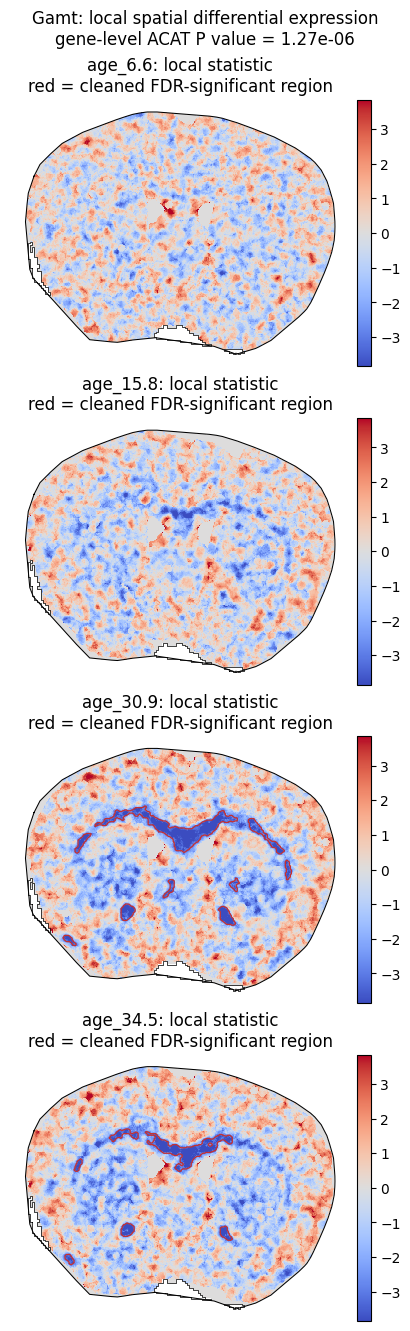

In [6]:
figure = plot_local_result(
    result,
    "Gamt",
    show_expression=False,
)